In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import json
import os
from scipy.optimize import curve_fit

mpl.rcParams.update({
    'font.size': 13
})

def lin(x, a):
    return a*x

In [12]:
def distance(p1, v1, p2, v2):

    vavg = (v1 + v2) / 2
    vn = vavg / np.linalg.norm(vavg)
    dp = p1 - p2
    dist = (dp[0] * vn[1] - vn[0] * dp[1]) * 1e3 # mm

    return dist

In [13]:
data_path = '/home/smarci/workspace/poloidal_flow/plots/cvoutput/'

In [14]:
with open('/home/smarci/workspace/poloidal_flow/reltor.json', 'rb') as f:
    shot_groups = json.load(f)

In [15]:
voltage_diffs = []
distances = []
distances_err = []
group_ids = []

for (group_idx, group) in enumerate(shot_groups):
    
    params = []
    voltages = []
    
    for exp_id in group.keys():
        
        try:
            p = np.loadtxt(f'/home/smarci/workspace/poloidal_flow/plots/cvoutput/{exp_id}_fit_data.txt')
        except:
            continue
        
        params.append(p)
        voltages.append(group[exp_id])
        
    if len(params) <= 1:
        continue
    
    for i in range(len(params) - 1):
        for j in range(i + 1, len(params)):
            
            vi = params[i][:2]
            pi = params[i][2:]
            vj = params[j][:2]
            pj = params[j][2:]
            
            dij = abs(distance(pi, vi, pj, vj))
            Uij = abs(voltages[i] - voltages[j])
            
            voltage_diffs.append(float(Uij))
            distances.append(dij)
            group_ids.append(group_idx)
            
voltage_diffs = np.array(voltage_diffs)
distances = np.array(distances)

In [16]:
voltage_diffs = np.delete(voltage_diffs, 6)
distances = np.delete(distances, 6)

In [17]:
popt, pcov = curve_fit(lin, voltage_diffs, distances)

In [18]:
unique_groups = sorted(set(group_ids))
cmap = mpl.colormaps['hsv'].resampled(len(unique_groups))
colors = [cmap(unique_groups.index(g)) for g in group_ids]

del colors[6]

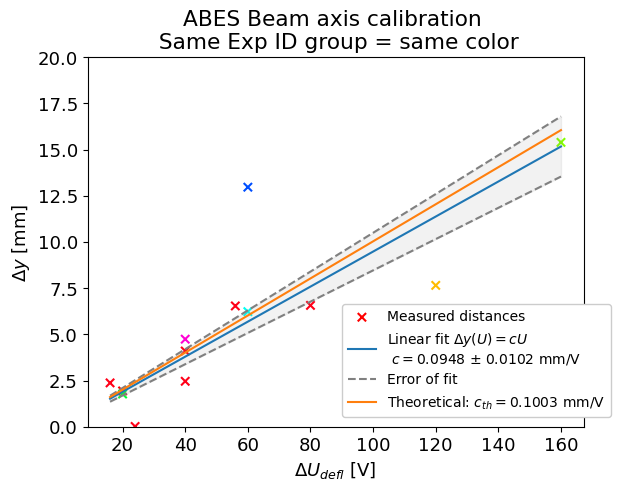

In [19]:
perr = np.sqrt(pcov[0])[0]

c_theoretical = 0.1003158

x = np.linspace(min(voltage_diffs), max(voltage_diffs), 5)

plt.figure()

plt.scatter(voltage_diffs, distances, marker='x', c=colors, label = 'Measured distances')
plt.plot(x, lin(x, popt), lw = 1.5, label = f'Linear fit $\\Delta y(U) = cU$ \n $c = {popt[0]:.4f}$ $\\pm$ ${np.sqrt(pcov[0])[0]:.4f}$ mm/V')

y1 = lin(x, popt + perr)
y2 = lin(x, popt - perr)

plt.plot(x, lin(x, popt + perr), lw = 1.5, ls = 'dashed', c = 'grey', label = f'Error of fit')
plt.plot(x, lin(x, popt - perr), lw = 1.5, ls = 'dashed', c = 'grey')

plt.fill_between(x, y1, y2, color = 'grey', alpha = 0.1)

plt.plot(x, c_theoretical*x, label = f'Theoretical: $c_{{th}} = {c_theoretical:.4f}$ mm/V')

plt.title('ABES Beam axis calibration \n Same Exp ID group = same color')
plt.xlabel('$\\Delta U_{defl}$ [V]')
plt.ylabel('$\\Delta y$ [mm]')

plt.legend(bbox_to_anchor = (0.5, 0.35), fontsize = 10, framealpha = True)
plt.ylim(0, 20)
plt.savefig('calib_plot.pdf')

In [21]:
np.sqrt(pcov)

array([[0.01016466]])